# De l'énergie de corrélation à une probabilité de stress

**Le problème.** Le modèle SIS donne $x_i(t)\in[0,1]$ = *probabilité* que l'actif
$i$ soit « infecté ». On aimerait le comparer à un observable réel. Jusqu'ici on
le comparait à l'**énergie de corrélation**
$$E_i(t) = \frac{1}{N-1}\sum_{j\neq i} |\rho_{ij}(t)|,$$
la corrélation absolue moyenne de l'actif au reste du marché. Mais $E_i$ vit sur
$[0,1]$ **sans être une probabilité** : comparer une probabilité ($x_i^{SIS}$) à
une énergie ($E_i$) n'a pas d'unité commune.

**L'idée.** Transformer $E_i$ en une vraie probabilité, sans changer la variable,
en la **calibrant** sur un événement de marché indépendant : un rendement extrême.

Ce notebook déroule l'idée étape par étape, chaque étape avec un graphe.

In [1]:
import sys
sys.path.insert(0, '../code')
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

from data import build_context
import analysis, model, config

ctx = build_context()                          # données + E_i journalier + matrices A (cache)
E   = ctx.E_daily_all                          # (N, jours) énergie de corrélation
R   = analysis.daily_log_returns(ctx.data, ctx.all_days)   # rendements journaliers
I   = analysis.extreme_indicator(R, q=0.90)       # 1 si |rendement| dans le top 10% de l'actif
days = pd.to_datetime(ctx.all_days)
print(f"{ctx.N} actifs, {len(ctx.all_days)} jours")

N = 146 actifs, T = 13360 obs ; 2019-04-01 10:00:00 -> 2023-05-03 15:30:00
[cache] OK  base
1031 jours ; <|C_ij|> moyen = 0.4686
146 actifs, 1031 jours


## 1. Le point de départ : $E_i$ n'est pas une probabilité

$E_i$ mesure à quel point un actif bouge « en phase » avec le marché ce jour-là.
Sa distribution s'étale de 0 à ~0.9 : ce sont des **niveaux de corrélation**, pas
des probabilités.

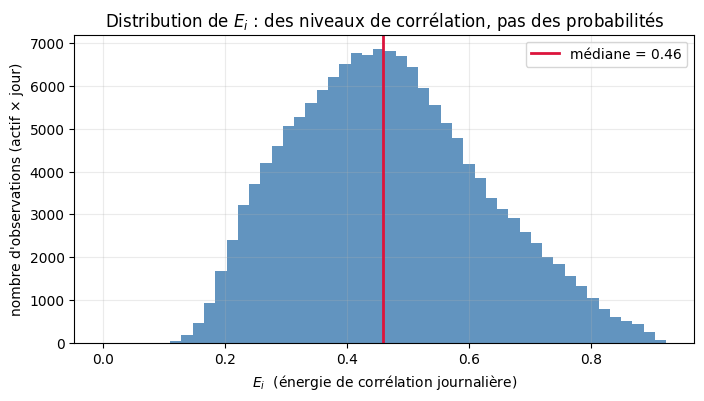

In [2]:
Ev = E[np.isfinite(E)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Ev, bins=50, color='steelblue', alpha=0.85)
ax.axvline(np.median(Ev), color='crimson', lw=2, label=f'médiane = {np.median(Ev):.2f}')
ax.set_xlabel(r'$E_i$  (énergie de corrélation journalière)')
ax.set_ylabel("nombre d'observations (actif × jour)")
ax.set_title(r"Distribution de $E_i$ : des niveaux de corrélation, pas des probabilités")
ax.legend(); ax.grid(alpha=0.25)
plt.show()

## 2. Un événement indépendant : le rendement extrême $I_i$

Pour chaque actif, on marque ses journées les plus violentes :
$$I_i(t) = \mathbf{1}\big(|r_i(t)| > q_i^{90}\big),$$
où $q_i^{90}$ est le 90ᵉ centile de $|r_i|$ **propre à l'actif** (donc ~10 % de
journées « extrêmes » par actif). Rien à voir avec les corrélations : c'est
purement l'amplitude du rendement.

Ci-dessous, un actif en exemple : ses journées extrêmes (points rouges) se
concentrent dans les périodes de tension.

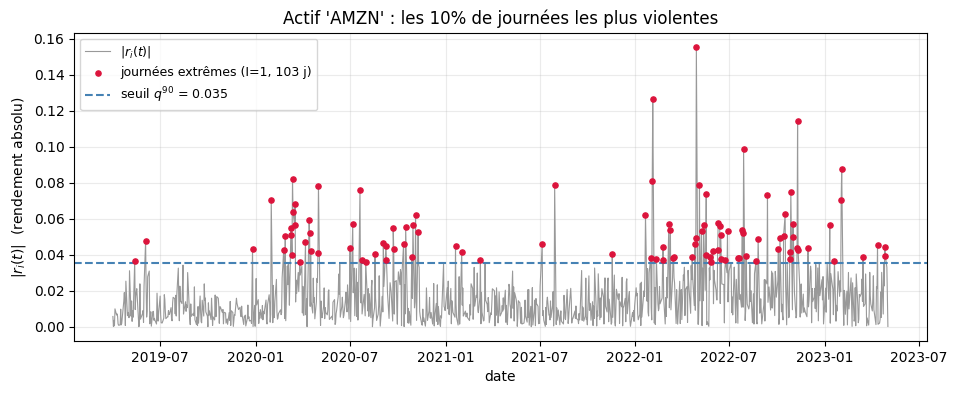

In [3]:
gi = ctx.asset_names.index('AMZN') if 'AMZN' in ctx.asset_names else 0
name = ctx.asset_names[gi]
absr = np.abs(R[gi])
thr  = np.nanquantile(absr, 0.90)              # seuil q90 de cet actif
ex   = absr > thr                              # journées extrêmes (I=1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(days, absr, color='0.6', lw=0.8, label=r'$|r_i(t)|$')
ax.scatter(days[ex], absr[ex], s=14, color='crimson', zorder=3,
           label=f'journées extrêmes (I=1, {ex.sum()} j)')
ax.axhline(thr, color='steelblue', lw=1.5, ls='--', label=f'seuil $q^{{90}}$ = {thr:.3f}')
ax.set_xlabel('date'); ax.set_ylabel(r'$|r_i(t)|$  (rendement absolu)')
ax.set_title(f"Actif '{name}' : les 10% de journées les plus violentes")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.show()

## 3. La calibration : $P(I=1 \mid E)$

On rassemble toutes les paires $(E_i(t), I_i(t))$ sur tous les actifs et tous les
jours. Puis, pour chaque tranche de $E$ (bin), on calcule la **fraction** de
journées extrêmes :
$$\xi_{emp}(E\text{-bin}) = \frac{\#\{I=1 \text{ dans le bin}\}}{\#\{\text{obs dans le bin}\}}.$$

Si $E$ élevé annonce vraiment plus de stress, cette courbe doit **monter**.

150526 paires (E, I) ; P(I=1) moyen = 0.100
xi_emp dépasse la moyenne (0.10) à partir de E* = 0.51


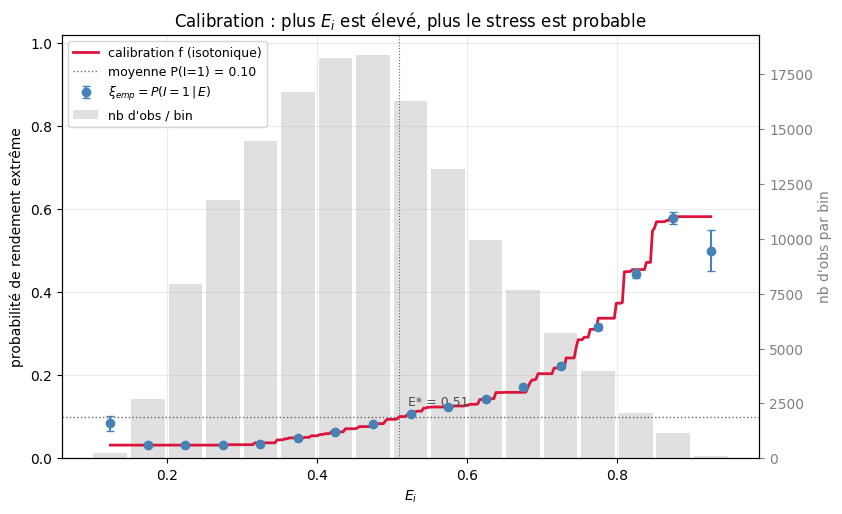

In [4]:
mp  = analysis.build_mapping(ctx, q=0.90, kind='isotonic')
cur = mp.curve
grid = np.linspace(cur['centers'].min(), cur['centers'].max(), 300)
E_star = analysis.crossing(grid, mp.iso(grid), mp.marginal)
print(f"{mp.Ev.size} paires (E, I) ; P(I=1) moyen = {mp.marginal:.3f}")
print(f"xi_emp dépasse la moyenne ({mp.marginal:.2f}) à partir de E* = {E_star:.2f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
axb = ax.twinx()
axb.bar(cur['centers'], cur['n'], width=0.045, color='0.88', zorder=0, label='nb d\'obs / bin')
axb.set_ylabel("nb d'obs par bin", color='0.5'); axb.tick_params(axis='y', colors='0.5')
axb.set_zorder(0); ax.set_zorder(1); ax.patch.set_visible(False)

ax.errorbar(cur['centers'], cur['p'], yerr=cur['se'], fmt='o', ms=6, color='steelblue',
            ecolor='steelblue', capsize=3, zorder=4, label=r'$\xi_{emp}=P(I=1\,|\,E)$')
ax.plot(grid, mp.iso(grid), color='crimson', lw=2, zorder=3, label='calibration f (isotonique)')
ax.axhline(mp.marginal, color='0.4', lw=1, ls=':', zorder=2,
           label=f'moyenne P(I=1) = {mp.marginal:.2f}')
if E_star is not None:
    ax.axvline(E_star, color='0.4', lw=0.8, ls=':', zorder=2)
    ax.annotate(f'E* = {E_star:.2f}', (E_star, mp.marginal), textcoords='offset points',
                xytext=(6, 8), fontsize=9, color='0.3')
ax.set_xlabel(r'$E_i$'); ax.set_ylabel('probabilité de rendement extrême')
ax.set_title(r'Calibration : plus $E_i$ est élevé, plus le stress est probable')
ax.set_ylim(0, max(1.0, cur['p'].max() + cur['se'].max()) * 1.02); ax.grid(alpha=0.25)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9)
plt.show()

La courbe **monte** (de ~3 % à ~58 %) : $E_i$ prédit bien le rendement extrême.
Elle croise la moyenne (10 %) vers $E^*\approx0.5$ — au-delà, un actif est plus
stressé que la moyenne.

## 4. La fonction de conversion $f : E \mapsto$ probabilité

La courbe ci-dessus **est** la fonction $f$ qui convertit n'importe quel $E$ en
probabilité. Deux versions : isotonique (colle aux données) et logistique
(lisse). C'est elle qu'on applique ensuite à $E_i(t)$ pour obtenir
$\xi_{emp}(t)=f(E_i(t))$.

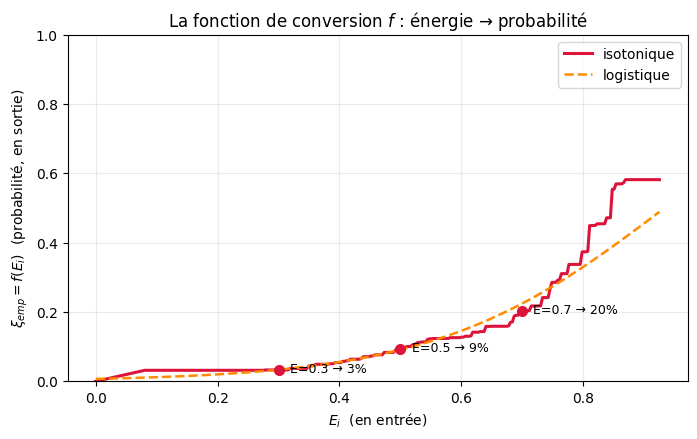

In [5]:
Eg = np.linspace(0, cur['centers'].max(), 300)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(Eg, mp.iso(Eg), color='crimson', lw=2.2, label='isotonique')
ax.plot(Eg, mp.log(Eg), color='darkorange', lw=1.8, ls='--', label='logistique')
for e in (0.3, 0.5, 0.7):
    y = float(mp.iso([e])[0])
    ax.plot(e, y, 'o', color='crimson', ms=7)
    ax.annotate(f'E={e} → {y:.0%}', (e, y), textcoords='offset points',
                xytext=(8, -2), fontsize=9)
ax.set_xlabel(r'$E_i$  (en entrée)')
ax.set_ylabel(r'$\xi_{emp}=f(E_i)$  (probabilité, en sortie)')
ax.set_title(r'La fonction de conversion $f$ : énergie → probabilité')
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.25)
plt.show()

## 5. Comparaison dynamique : $x_i^{SIS}(t)$ vs $\xi_{emp}(t)$

Maintenant les deux courbes sont des **probabilités** → on peut les superposer.
On garde le pipeline SIS tel quel et on sélectionne l'actif le mieux ajusté d'une
crise. Comme $x_i^{SIS}$ **est** une probabilité, on l'initialise dans le même
espace : $x_0 = f(E(\text{jour }0)) = \xi_{emp}(0)$ (et non $E_i$ brut). Ainsi les
deux probabilités **partent exactement du même point**, et la comparaison de leur
évolution est propre.

[cache] OK  crisis_map


Actif 'AMZN' — 2019-04-01 → 2019-05-13
  x_SIS(0) = 0.013   xi_emp(0) = 0.013   → départs alignés


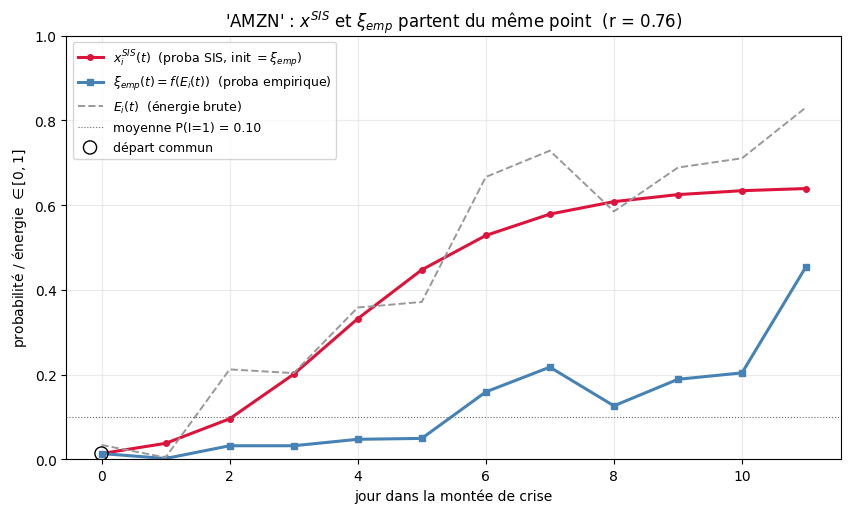

In [6]:
P  = analysis.load_periods(ctx)
fc = model.make_fit_context(ctx, P['crisis_map'])
A  = ctx.A_sis['PMFG']

best = None
for (pa, pb) in P['intervals_chrono']:
    if pb - pa + 1 < 30:
        continue
    cache = model.cache_signed(pa, pb, fc)
    for gg, d in cache.items():
        E_i = d['E_i']; ok = ~np.isnan(E_i)
        if ok.sum() < 5:
            continue
        xt = model.integrate_fast(d, gg, A)
        r2 = linregress(E_i[ok], xt[ok]).rvalue ** 2
        if best is None or r2 > best[0]:
            best = (r2, pa, pb, gg, d)

r2, pa, pb, g, d = best
nm    = ctx.asset_names[g]
E_i   = d['E_i']
# SIS initialisé dans l'espace de probabilité : x0 = f(E au jour 0)
d_pb  = dict(d, x0=analysis.map_energy(d['x0'], mp.f))
xt    = model.integrate_fast(d_pb, g, A)              # part de xi_emp(0)
xi_emp = analysis.map_energy(E_i, mp.f)
ok    = ~np.isnan(E_i)
r_se  = pearsonr(xt[ok], xi_emp[ok])[0]
print(f"Actif '{nm}' — {ctx.all_days[pa]} → {ctx.all_days[pb]}")
print(f"  x_SIS(0) = {xt[0]:.3f}   xi_emp(0) = {xi_emp[0]:.3f}   → départs alignés")

t = np.arange(len(E_i))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(t, xt, color='crimson', lw=2.2, marker='o', ms=4,
        label=r'$x_i^{SIS}(t)$  (proba SIS, init $=\xi_{emp}$)')
ax.plot(t, xi_emp, color='steelblue', lw=2.2, marker='s', ms=4,
        label=r'$\xi_{emp}(t)=f(E_i(t))$  (proba empirique)')
ax.plot(t, E_i, color='0.6', lw=1.4, ls='--', label=r'$E_i(t)$  (énergie brute)')
ax.axhline(mp.marginal, color='0.4', lw=0.8, ls=':', label=f'moyenne P(I=1) = {mp.marginal:.2f}')
ax.scatter([0], [xt[0]], s=90, facecolors='none', edgecolors='black', zorder=5,
           label='départ commun')
ax.set_xlabel('jour dans la montée de crise'); ax.set_ylabel(r'probabilité / énergie $\in[0,1]$')
ax.set_title(f"'{nm}' : $x^{{SIS}}$ et $\\xi_{{emp}}$ partent du même point  (r = {r_se:.2f})")
ax.set_ylim(0, 1); ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.show()

## En résumé

1. $E_i$ = énergie de corrélation, sur $[0,1]$ mais **pas** une probabilité.
2. $I_i$ = journée à rendement extrême (top 10 % par actif), critère **indépendant**.
3. La fraction de journées extrêmes par tranche de $E$ donne une **vraie
   probabilité** $\xi_{emp}=P(I=1\,|\,E)$, croissante.
4. La fonction $f$ convertit $E_i(t)$ en $\xi_{emp}(t)$.
5. On compare alors $x_i^{SIS}(t)$ et $\xi_{emp}(t)$ — **deux probabilités** — sur
   le même graphe.

Comme $f$ est croissante, l'ordre des actifs ne change pas : $\xi_{emp}$ rend la
comparaison légitime en **unités**, sans modifier le classement.